# Políticas — Grosor de cartón

Exploración visual de políticas de grosor único vs mezcla (2.5, 2.7 y 3 mm).

| Grosor (mm) | ECT (N/m) |
|------------:|----------:|
| 2,5 | 600 |
| 2,7 | 730 |
| 3,0 | 1000 |
| 4,1 | 1200 |
| 4,5 | 1400 |
| 4,6 | 1450 |
| 4,7 | 1500 |
| 4,8 | 1550 |
| 5,0 | 1650 |

**Comparación principal:** Mark 17 from minbox (óptimo del surrogate demand-free) para cada grosor / mezcla, evaluado con costo Kaggle plant-tier.

**Cota analítica (§2):** piso teórico (flete mín. por SKU + packaging a tier 5), solo como referencia.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display

_candidates = [Path.cwd(), Path.cwd().parent, Path("..").resolve()]
ROOT = next(p for p in _candidates if (p / "data" / "raw" / "operaciones_planta.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

from evaluate import (
    COSTO_PALLET,
    SUBMISSION_COLS,
    calcular_cajas_por_pallet,
    costo_flete_eval,
    factor_precio_por_volumen,
    preparar_eval_planta,
    validate_solution_free,
)
from mark16 import (
    _cands_eje,
    construir_productos,
    costo_actual_oficial,
    intervalos,
    score_publico,
)
from settings import (
    ECT,
    EPS,
    GRAVITY,
    LIM,
    PLANTAS,
    PRECIO_BASE_GROSOR,
)


def evaluar_kaggle(sol: pd.DataFrame, ops_df: pd.DataFrame) -> dict:
    """Packaging con tier/descuento por planta + flete (alineado a truth table / Kaggle)."""
    df = preparar_eval_planta(sol[SUBMISSION_COLS], ops_df)
    df = calcular_cajas_por_pallet(df)
    precio_base = (
        df.groupby("tipo")["caja_grosor_mm"].first().round(1).map(PRECIO_BASE_GROSOR)
    )
    if precio_base.isna().any():
        raise ValueError("Grosores sin precio base")
    pack = 0.0
    for planta in PLANTAS:
        vol_tp = df.groupby("tipo")[f"volumen_producto_planta_{planta}"].sum()
        factor = factor_precio_por_volumen(vol_tp)
        pack += float((vol_tp.values * precio_base.loc[vol_tp.index].values * factor).sum())
    flete = float(costo_flete_eval(df))
    return {
        "n_tipos": int(df["tipo"].nunique()),
        "packaging": pack,
        "flete": flete,
        "total": pack + flete,
        "df": df,
    }

# --- Paleta (notebook 190) ---
GREEN = "#5CAC31"
GRAY = "#706F6F"
GREEN_DARK = "#3B7434"
LIGHT_GRAY = "#DADADA"
ACCENT = "#E45756"
BG = "#FFFFFF"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": LIGHT_GRAY,
    "axes.labelcolor": GRAY,
    "axes.titlecolor": GREEN_DARK,
    "xtick.color": GRAY,
    "ytick.color": GRAY,
    "text.color": GRAY,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": False,
    "legend.frameon": False,
})


def style_ax(ax, title: str, subtitle: str | None = None):
    ax.set_facecolor(BG)
    ax.spines["bottom"].set_color(LIGHT_GRAY)
    ax.tick_params(length=0, colors=GRAY, labelsize=9)
    ax.yaxis.grid(True, color=LIGHT_GRAY, linewidth=0.8)
    ax.set_axisbelow(True)
    y_title = 1.16 if subtitle else 1.06
    ax.text(
        0.0, y_title, title,
        transform=ax.transAxes, fontsize=12, fontweight="bold",
        color=GREEN_DARK, va="bottom", ha="left", clip_on=False,
    )
    if subtitle:
        ax.text(
            0.0, 1.06, subtitle,
            transform=ax.transAxes, fontsize=9,
            color=GRAY, va="bottom", ha="left", clip_on=False,
        )


def annotate_bars(ax, bars, fmt, color=GRAY, fontsize=9):
    for bar in bars:
        h = bar.get_height()
        if not np.isfinite(h) or h <= 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2, h,
            fmt(h), ha="center", va="bottom",
            color=color, fontsize=fontsize,
        )


def finish_fig(fig):
    fig.patch.set_facecolor(BG)
    fig.tight_layout(rect=[0, 0, 1, 0.88])
    fig.subplots_adjust(top=0.78)
    plt.show()


ops = pd.read_csv(ROOT / "data/raw/operaciones_planta.csv")
pt = pd.read_csv(ROOT / "data/processed/products_truth.csv")
esp = pd.read_csv(ROOT / "data/raw/especificaciones_cajas.csv")
proc = pd.read_csv(ROOT / "data/raw/procurement_cajas.csv")
cat = pd.read_csv(ROOT / "data/raw/catalogo_productos.csv")

prod = construir_productos(pt, ops)
BASELINE = costo_actual_oficial(ops)

dims = prod[["largo", "ancho", "alto"]].to_numpy(float)
peso = prod["peso_neto_caja"].to_numpy(float)
volp = prod[[f"volumen_producto_planta_{p}" for p in PLANTAS]].to_numpy(float)
vol_total = float(prod["volumen_producto_total"].sum())
codes = prod["codigo_producto"].astype(str).tolist()

MARK17_3MM_PATH = ROOT / "outputs/mark17/mark17_from_minbox.csv"
GROSOR_SUMMARY_PATH = ROOT / "outputs/tables/200_mark17_grosor_minbox.csv"
GROSOR_SOL_DIR = ROOT / "outputs/mark17/grosor"

print(f"Baseline oficial: USD {BASELINE:,.0f}")
print(f"SKUs: {len(prod)} | volumen anual: {vol_total:,.0f} cajas")
print(f"Grosores ECT: {sorted(ECT)}")
print(f"Mark17 3 mm: {MARK17_3MM_PATH.relative_to(ROOT)}")
print(f"Summary sweep: {GROSOR_SUMMARY_PATH.relative_to(ROOT)}")


Baseline oficial: USD 209,235,094
SKUs: 427 | volumen anual: 62,420,911 cajas
Grosores ECT: [2.5, 2.7, 3.0, 4.1, 4.5, 4.6, 4.7, 4.8, 5.0]
Mark17 3 mm: outputs/mark17/mark17_from_minbox.csv
Summary sweep: outputs/tables/200_mark17_grosor_minbox.csv


## 1. Precio base por grosor (inferido del raw)

En `procurement_cajas.csv` el `costo_unitario_base` está por tipo de caja. Uniendo con `especificaciones_cajas.caja_grosor_mm` se infiere el precio USD/caja de cada grosor histórico.

La política Kaggle agrupa en {3,0 · 4,5 · 5,0}; los grosores finos del histórico heredan el mismo precio base dentro de cada bucket.


In [2]:
def normalize_grosor(x) -> float:
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower().replace("mm", "").replace(" ", "").replace(",", ".")
    try:
        return round(float(s), 1)
    except ValueError:
        return np.nan


tipos = (
    esp[["caja_tipo_id", "caja_grosor_mm"]]
    .merge(proc[["caja_tipo_id", "costo_unitario_base"]], on="caja_tipo_id", how="inner")
)
tipos["grosor_mm"] = tipos["caja_grosor_mm"].map(normalize_grosor)

precio_hist = (
    tipos.groupby("grosor_mm", dropna=False)
    .agg(
        n_tipos=("caja_tipo_id", "nunique"),
        precio_min=("costo_unitario_base", "min"),
        precio_max=("costo_unitario_base", "max"),
        precio_base=("costo_unitario_base", "first"),
    )
    .reset_index()
    .sort_values("grosor_mm")
)

# ¿Coincide 1:1 grosor → precio?
assert (precio_hist["precio_min"] == precio_hist["precio_max"]).all(), "Precio no único por grosor"

# Productos baseline por grosor histórico
por_prod = (
    ops[["codigo_producto", "volumen_producto_total", "costo_total"]]
    .merge(cat.drop_duplicates("codigo_producto")[["codigo_producto", "caja_tipo_id"]], on="codigo_producto")
    .merge(tipos[["caja_tipo_id", "grosor_mm", "costo_unitario_base"]], on="caja_tipo_id")
)

resumen_precio = (
    por_prod.groupby("grosor_mm")
    .agg(
        n_skus=("codigo_producto", "count"),
        volumen=("volumen_producto_total", "sum"),
        precio_base=("costo_unitario_base", "first"),
    )
    .reset_index()
    .sort_values("grosor_mm")
)

# Tabla completa: ECT + precio settings (incluye 3.0 / 5.0 de política aunque no estén en histórico)
tabla_g = pd.DataFrame({
    "grosor_mm": sorted(ECT.keys()),
    "ECT_N_m": [ECT[g] for g in sorted(ECT.keys())],
    "precio_settings": [PRECIO_BASE_GROSOR[g] for g in sorted(ECT.keys())],
}).merge(
    resumen_precio.rename(columns={"precio_base": "precio_raw", "n_skus": "n_skus_hist"}),
    on="grosor_mm",
    how="left",
)

print("Inferencia raw: cada grosor histórico tiene un único costo_unitario_base\n")
display(
    tabla_g.style.format({
        "grosor_mm": "{:.1f}",
        "precio_settings": "${:.2f}",
        "precio_raw": "${:.2f}",
        "volumen": "{:,.0f}",
        "n_skus_hist": "{:.0f}",
    }, na_rep="— (no en histórico)")
)

print(
    "\nBuckets de precio: "
    "$0.60 → 2.5/2.7/(3.0) · $0.65 → 4.1/4.5 · $0.70 → 4.6/4.7/4.8/(5.0)"
)
print("3.0 y 5.0 no aparecen como grosor histórico; se les asigna el precio del bucket (settings).")


Inferencia raw: cada grosor histórico tiene un único costo_unitario_base



,grosor_mm,ECT_N_m,precio_settings,n_skus_hist,volumen,precio_raw
0,2.5,600,$0.60,7,"2,758,110",$0.60
1,2.7,730,$0.60,158,"25,384,147",$0.60
2,3.0,1000,$0.60,— (no en histórico),— (no en histórico),— (no en histórico)
3,4.1,1200,$0.65,184,"28,273,705",$0.65
4,4.5,1400,$0.65,5,"730,918",$0.65
5,4.6,1450,$0.70,38,"1,404,948",$0.70
6,4.7,1500,$0.70,2,"87,507",$0.70
7,4.8,1550,$0.70,33,"3,781,576",$0.70
8,5.0,1650,$0.70,— (no en histórico),— (no en histórico),— (no en histórico)



Buckets de precio: $0.60 → 2.5/2.7/(3.0) · $0.65 → 4.1/4.5 · $0.70 → 4.6/4.7/4.8/(5.0)
3.0 y 5.0 no aparecen como grosor histórico; se les asigna el precio del bucket (settings).


## 2. Cota analítica por grosor único

Para cada `g`: maximizar `cpp` por SKU bajo regla 9 (ventana geométrica + ECT + pallet).  
Packaging piso = `precio_base(g) × 0.70 × volumen_total` (tier máximo del evaluador por planta/volumen).

Si algún SKU no tiene caja factible → política **no viable**.


In [3]:
def cota_analitica(g: float) -> dict:
    """Piso de costo con grosor único g (consolidación relajada)."""
    lo, hi, vol_min = intervalos(prod, g)
    cpp_best = np.zeros(len(dims), dtype=int)
    fail_codes = []

    for i in range(len(dims)):
        cands = [
            _cands_eje(float(lo[i, k]), float(hi[i, k]), LIM[k], g) for k in range(3)
        ]
        best = 0
        for L in cands[0]:
            a = int(np.floor(LIM[0] / (L + 2 * g)))
            for W in cands[1]:
                b = int(np.floor(LIM[1] / (W + 2 * g)))
                carga_max = ECT[g] * 2 * (L + W + 4 * g) / 1000.0 / GRAVITY
                for H in cands[2]:
                    if L * W * H < vol_min[i] - 1e-6:
                        continue
                    c = int(np.floor(LIM[2] / (H + 2 * g)))
                    if a < 1 or b < 1 or c < 1:
                        continue
                    if peso[i] * (c - 1) > carga_max + EPS:
                        continue
                    if a * b * c > best:
                        best = a * b * c
        if best == 0:
            fail_codes.append(codes[i])
        else:
            cpp_best[i] = best

    if fail_codes:
        return {
            "grosor_mm": g,
            "viable": False,
            "n_fail": len(fail_codes),
            "precio_base": PRECIO_BASE_GROSOR[g],
            "ECT": ECT[g],
        }

    flete = float((np.ceil(volp / cpp_best[:, None]) * COSTO_PALLET).sum())
    pack = PRECIO_BASE_GROSOR[g] * 0.70 * vol_total
    total = flete + pack
    return {
        "grosor_mm": g,
        "viable": True,
        "n_fail": 0,
        "precio_base": PRECIO_BASE_GROSOR[g],
        "ECT": ECT[g],
        "flete_piso": flete,
        "pack_piso": pack,
        "total_piso": total,
        "score_techo": score_publico(total, BASELINE),
    }


GROSORES = sorted(ECT.keys())
cotas = {g: cota_analitica(g) for g in GROSORES}
ref_3 = cotas[3.0]["total_piso"] if cotas[3.0]["viable"] else np.nan

rows = []
for g in GROSORES:
    r = cotas[g]
    row = {
        "grosor_mm": g,
        "ECT": r["ECT"],
        "precio_base": r["precio_base"],
        "viable": r["viable"],
        "n_fail_ECT": r["n_fail"],
    }
    if r["viable"]:
        row.update({
            "flete_piso": r["flete_piso"],
            "pack_piso": r["pack_piso"],
            "total_piso": r["total_piso"],
            "score_techo": r["score_techo"],
            "delta_vs_3": r["total_piso"] - ref_3,
        })
    rows.append(row)

tabla_cotas = pd.DataFrame(rows)

print("COTA POR GROSOR ÚNICO")
display(
    tabla_cotas.style.format({
        "grosor_mm": "{:.1f}",
        "precio_base": "${:.2f}",
        "flete_piso": "{:,.0f}",
        "pack_piso": "{:,.0f}",
        "total_piso": "{:,.0f}",
        "score_techo": "{:+.2f}",
        "delta_vs_3": "{:+,.0f}",
    }, na_rep="—")
)

no_viable = tabla_cotas.loc[~tabla_cotas["viable"], ["grosor_mm", "n_fail_ECT"]]
if len(no_viable):
    print("No viables como política única:")
    for _, r in no_viable.iterrows():
        print(f"  g={r.grosor_mm:.1f} mm — {int(r.n_fail_ECT)} SKUs fallan ECT")


COTA POR GROSOR ÚNICO


,grosor_mm,ECT,precio_base,viable,n_fail_ECT,flete_piso,pack_piso,total_piso,score_techo,delta_vs_3
0,2.5,600,$0.60,False,69,—,—,—,—,—
1,2.7,730,$0.60,False,13,—,—,—,—,—
2,3.0,1000,$0.60,True,0,"161,104,650","26,216,783","187,321,433",+10.47,+0
3,4.1,1200,$0.65,True,0,"165,175,200","28,401,515","193,576,715",+7.48,"+6,255,282"
4,4.5,1400,$0.65,True,0,"165,968,100","28,401,515","194,369,615",+7.10,"+7,048,182"
5,4.6,1450,$0.70,True,0,"164,904,300","30,586,246","195,490,546",+6.57,"+8,169,114"
6,4.7,1500,$0.70,True,0,"165,003,600","30,586,246","195,589,846",+6.52,"+8,268,414"
7,4.8,1550,$0.70,True,0,"165,105,900","30,586,246","195,692,146",+6.47,"+8,370,714"
8,5.0,1650,$0.70,True,0,"166,336,650","30,586,246","196,922,896",+5.88,"+9,601,464"


No viables como política única:
  g=2.5 mm — 69 SKUs fallan ECT
  g=2.7 mm — 13 SKUs fallan ECT


## 3. ¿Qué tan económica puede ser una distribución para cada grosor?

Primera barra = **Actual** (baseline oficial). El resto = **costo total Kaggle** (USD M) de Mark 17 from minbox al forzar un único grosor (óptimo del surrogate demand-free).

```bash
PYTHONPATH=src python scripts/run_mark17_grosor_sweep.py --workers 6 --time-limit 900
```


MARK17 FROM MINBOX — GROSOR ÚNICO


,grosor_mm,total,score,n_tipos,optimal_surrogate,elapsed_s,solution_path
0,3.0,"189,197,949",+9.57638,41,True,0,outputs/mark17/grosor/mark17_minbox_g3.csv
1,4.1,"195,783,030",+6.42916,39,True,148,outputs/mark17/grosor/mark17_minbox_g4.1.csv
2,4.5,"196,442,934",+6.11377,40,True,86,outputs/mark17/grosor/mark17_minbox_g4.5.csv
3,4.6,"197,373,819",+5.66887,38,False,903,outputs/mark17/grosor/mark17_minbox_g4.6.csv
4,4.7,"197,392,800",+5.65980,36,True,163,outputs/mark17/grosor/mark17_minbox_g4.7.csv
5,4.8,"197,856,645",+5.43812,37,False,903,outputs/mark17/grosor/mark17_minbox_g4.8.csv
6,5.0,"198,743,113",+5.01445,36,False,903,outputs/mark17/grosor/mark17_minbox_g5.csv


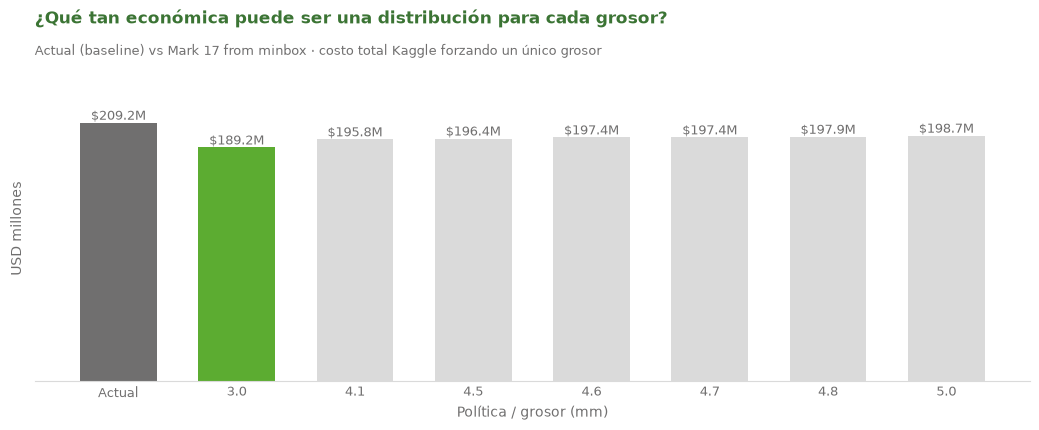

Guardado: outputs/tables/200_mark17_por_grosor.csv


In [6]:
assert GROSOR_SUMMARY_PATH.exists(), (
    f"Falta {GROSOR_SUMMARY_PATH.relative_to(ROOT)}. "
    "Correr: PYTHONPATH=src python scripts/run_mark17_grosor_sweep.py"
)
sweep = pd.read_csv(GROSOR_SUMMARY_PATH)
unico = sweep[sweep["ok"] & ~sweep["grosores"].astype(str).str.contains(",")].copy()
unico["grosor_mm"] = unico["grosores"].astype(float)
unico = unico.sort_values("grosor_mm")

print("MARK17 FROM MINBOX — GROSOR ÚNICO")
display(
    unico[
        ["grosor_mm", "total", "score", "n_tipos", "optimal_surrogate", "elapsed_s", "solution_path"]
    ].style.format(
        {
            "grosor_mm": "{:.1f}",
            "total": "{:,.0f}",
            "score": "{:+.5f}",
            "elapsed_s": "{:,.0f}",
        },
        na_rep="—",
    )
)

labels = ["Actual"] + [f"{g:.1f}" for g in unico["grosor_mm"]]
totals = np.concatenate([[BASELINE / 1e6], unico["total"].to_numpy() / 1e6])
colors = [GRAY] + [
    GREEN if abs(g - 3.0) < 1e-9 else LIGHT_GRAY for g in unico["grosor_mm"]
]

fig, ax = plt.subplots(figsize=(10.5, 4.6))
bars = ax.bar(labels, totals, color=colors, width=0.65)
annotate_bars(ax, bars, lambda h: f"${h:.1f}M")
style_ax(
    ax,
    "¿Qué tan económica puede ser una distribución para cada grosor?",
    "Actual (baseline) vs Mark 17 from minbox · costo total Kaggle forzando un único grosor",
)
ax.set_xlabel("Política / grosor (mm)")
ax.set_ylabel("USD millones")
ax.set_ylim(0, totals.max() * 1.18)
ax.grid(False)
ax.set_yticklabels([])
finish_fig(fig)


# Guardar tabla de uniques (complementa la cota analítica)
out_unico = ROOT / "outputs/tables/200_mark17_por_grosor.csv"
unico.to_csv(out_unico, index=False)
print("Guardado:", out_unico.relative_to(ROOT))


## 4. ¿Es conveniente mezclar grosores?

Comparación **bajo el mismo protocolo** Mark 17 from minbox (evaluador tier por planta):

| Etiqueta | Política | Fuente |
|----------|----------|--------|
| **Bajo protocolo 3 mm** | grosor único 3,0 | `mark17_from_minbox.csv` |
| **Bajo protocolo (2.5, 2.7 y 3 mm)** | mezcla permitida | Mark17 warm minbox · `grosores=2.5,2.7,3.0` |


Bajo protocolo 3 mm:                    USD 189,197,949.24  score +9.57638  tipos 41
Bajo protocolo (2.5, 2.7 y 3 mm):       USD 187,639,511.46  score +10.32120
  pack 26.98M + flete 160.66M | tipos 43 | 2.5 / 2.7 / 3.0
Distribución: 81 SKUs @2.5 · 188 SKUs @2.7 · 158 SKUs @3.0
Ahorro mezcla vs protocolo 3 mm: USD 1,558,437.78  (+0.82371% · +0.74483 pts)
Surrogate óptimo mezcla: False | gap=12650.037000000011
Warnings:
- Solución seleccionada no cumple políticas de grosor único entre 3, 4.5 mm y 5


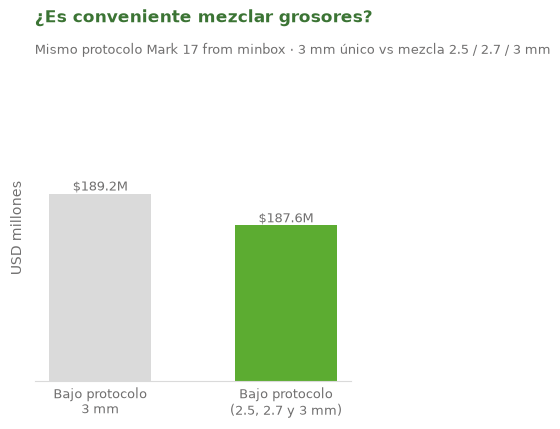

Guardado: outputs/tables/200_cota_por_grosor.csv


In [8]:
assert GROSOR_SUMMARY_PATH.exists(), (
    f"Falta {GROSOR_SUMMARY_PATH.relative_to(ROOT)}. "
    "Correr: PYTHONPATH=src python scripts/run_mark17_grosor_sweep.py"
)
sweep = pd.read_csv(GROSOR_SUMMARY_PATH)

# Bajo protocolo 3 mm (Mark17 from minbox — ya optimizado)
proto_3 = pd.read_csv(MARK17_3MM_PATH)[SUBMISSION_COLS].copy()
proto_3["codigo_producto"] = proto_3["codigo_producto"].astype(str).str.strip()
ev_3 = evaluar_kaggle(proto_3, ops)
cost_3 = float(ev_3["total"])
score_3 = score_publico(cost_3, BASELINE)
assert abs(cost_3 - 189_197_949.24) < 0.02, cost_3

# Bajo protocolo mezcla 2.5 / 2.7 / 3.0 — del sweep Mark17
mix_row = sweep[
    sweep["ok"] & sweep["grosores"].astype(str).str.contains("2.5")
].copy()
assert len(mix_row) >= 1, "Falta corrida mezcla 2.5,2.7,3.0 en el summary del sweep"
mix_row = mix_row.iloc[0]

mix_path = ROOT / str(mix_row["solution_path"])
assert mix_path.exists(), mix_path

mix = pd.read_csv(mix_path)[SUBMISSION_COLS].copy()
mix["codigo_producto"] = mix["codigo_producto"].astype(str).str.strip()
mix["caja_grosor_mm"] = pd.to_numeric(mix["caja_grosor_mm"]).round(1)

ok, errors, warnings, _ = validate_solution_free(mix, pt, verbose=False)
assert ok, errors

ev_mix = evaluar_kaggle(mix, ops)
cost_mix = float(ev_mix["total"])
pack_mix = float(ev_mix["packaging"])
flete_mix = float(ev_mix["flete"])
n_tipos_mix = int(ev_mix["n_tipos"])
score_mix = score_publico(cost_mix, BASELINE)
assert abs(cost_mix - float(mix_row["total"])) < 1.0, (cost_mix, mix_row["total"])

dist_g = mix["caja_grosor_mm"].value_counts().sort_index()
texto_mix = " / ".join(f"{g:.1f}" for g in dist_g.index)
detalle_mix = " · ".join(f"{int(n)} SKUs @{g:.1f}" for g, n in dist_g.items())
ahorro = cost_3 - cost_mix
ahorro_pct = 100.0 * ahorro / cost_3

print(f"Bajo protocolo 3 mm:                    USD {cost_3:,.2f}  score {score_3:+.5f}  tipos {ev_3['n_tipos']}")
print(f"Bajo protocolo (2.5, 2.7 y 3 mm):       USD {cost_mix:,.2f}  score {score_mix:+.5f}")
print(f"  pack {pack_mix/1e6:.2f}M + flete {flete_mix/1e6:.2f}M | tipos {n_tipos_mix} | {texto_mix}")
print(f"Distribución: {detalle_mix}")
print(
    f"Ahorro mezcla vs protocolo 3 mm: USD {ahorro:,.2f}  "
    f"({ahorro_pct:+.5f}% · {score_mix - score_3:+.5f} pts)"
)
print(
    f"Surrogate óptimo mezcla: {bool(mix_row.get('optimal_surrogate', False))} "
    f"| gap={mix_row.get('gap_surrogate', float('nan'))}"
)
if warnings:
    print("Warnings:", *warnings, sep="\n- ")

plot_labels = ["Bajo protocolo\n3 mm", "Bajo protocolo\n(2.5, 2.7 y 3 mm)"]
plot_vals = np.array([cost_3, cost_mix]) / 1e6
plot_colors = ["#DADADA", "#5CAC31"]

fig, ax = plt.subplots(figsize=(5, 4.6))
bars = ax.bar(plot_labels, plot_vals, color=plot_colors, width=0.55)
annotate_bars(ax, bars, lambda h: f"${h:.1f}M")
for bar in bars:
    bar.set_edgecolor("none")

style_ax(
    ax,
    "¿Es conveniente mezclar grosores?",
    "Mismo protocolo Mark 17 from minbox · 3 mm único vs mezcla 2.5 / 2.7 / 3 mm",
)
ax.set_ylabel("USD millones")
ymin = min(plot_vals.min() - 3, 180)
ymax = max(plot_vals.max() + 3, 195)
ax.set_ylim(ymin, ymax)
ax.grid(False)
ax.set_yticklabels([])
finish_fig(fig)

out_cota = ROOT / "outputs/tables/200_cota_por_grosor.csv"
tabla_cotas.to_csv(out_cota, index=False)
print("Guardado:", out_cota.relative_to(ROOT))


## 5. Fit volumen (líquidos) vs fit por eje (rígidos)

Misma lógica de protocolo **Mark 17 from minbox**, bajo dos lecturas de la regla 9:

| Base | Geometría | Corrida |
|------|-----------|---------|
| Productos “líquidos” | fit por volumen (lectura Kaggle) | `mark17_from_minbox` / mezcla grosor |
| Productos rígidos | fit por eje (Mark 19: `interna ≥ producto`) | `scripts/run_mark17_fisico.py` |

```bash
PYTHONPATH=src python scripts/run_mark17_fisico.py --grosores 3.0 --time-limit 900
PYTHONPATH=src python scripts/run_mark17_fisico.py --grosores 2.5,2.7,3.0 --time-limit 900
```


In [ ]:
from IPython.display import HTML

TABLA_PATH = ROOT / "outputs/tables/200_mark17_liquido_vs_rigido.csv"
assert TABLA_PATH.exists(), (
    f"Falta {TABLA_PATH.relative_to(ROOT)}. Correr mark17 líquido + "
    "`scripts/run_mark17_fisico.py` para rígidos."
)
tabla = pd.read_csv(TABLA_PATH)

def _cell(row) -> str:
    total_m = row["total"] / 1e6
    score = float(row["score"])
    cls = "neg" if score < 0 else "pos"
    return (
        f'US${total_m:,.1f} M · '
        f'<span class="{cls}">{score:+.2f}%</span>'
    ).replace(",", "X").replace(".", ",").replace("X", ".")

liq3 = tabla[(tabla["fit_model"] == "volume") & tabla["politica_grosor"].str.contains("Único")].iloc[0]
liqmix = tabla[(tabla["fit_model"] == "volume") & tabla["politica_grosor"].str.contains("Mezcla")].iloc[0]
rig3 = tabla[(tabla["fit_model"] == "physical_axis") & tabla["politica_grosor"].str.contains("Único")].iloc[0]
rigmix = tabla[(tabla["fit_model"] == "physical_axis") & tabla["politica_grosor"].str.contains("Mezcla")].iloc[0]

html = f"""
<style>
.fit-wrap {{ font-family: system-ui, sans-serif; max-width: 820px; }}
.fit-wrap .title {{ color: {GREEN_DARK}; font-weight: 700; font-size: 15px; margin: 0 0 4px; }}
.fit-wrap .sub {{ color: {GRAY}; font-size: 12px; margin: 0 0 12px; }}
.fit-table {{ border-collapse: collapse; width: 100%; font-size: 13px; }}
.fit-table th {{
  background: {GREEN}; color: white; font-weight: 600; text-align: center;
  padding: 10px 12px; border: 1px solid {GREEN_DARK};
}}
.fit-table th.stub {{ background: {GREEN_DARK}; text-align: left; width: 28%; }}
.fit-table td {{
  padding: 12px; border: 1px solid #cfd4c8; text-align: center; color: {GRAY};
  background: #f7f8f5;
}}
.fit-table td.stub {{
  text-align: left; font-weight: 600; color: {GREEN_DARK}; background: #eef3e8;
}}
.fit-table .pos {{ color: {GREEN}; font-weight: 700; }}
.fit-table .neg {{ color: #c0392b; font-weight: 700; }}
</style>
<div class="fit-wrap">
  <p class="title">Mark 17 (protocolo) · fit volumen vs fit por eje</p>
  <p class="sub">Costo total Kaggle (plant-tier) · % = saving vs baseline oficial</p>
  <table class="fit-table">
    <thead>
      <tr>
        <th class="stub">Base de diseño</th>
        <th>Grosor único 3,0 mm</th>
        <th>Mezcla 2,5 / 2,7 / 3,0 mm</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td class="stub">Productos “líquidos”</td>
        <td>{_cell(liq3)}</td>
        <td>{_cell(liqmix)}</td>
      </tr>
      <tr>
        <td class="stub">Productos rígidos</td>
        <td>{_cell(rig3)}</td>
        <td>{_cell(rigmix)}</td>
      </tr>
    </tbody>
  </table>
</div>
"""
display(HTML(html))

print("Detalle:")
display(
    tabla[
        ["base_diseno", "politica_grosor", "total", "score", "n_tipos", "fisico_ok", "n_con_achique", "path"]
    ].style.format({"total": "{:,.0f}", "score": "{:+.5f}"})
)
for _, r in tabla.iterrows():
    print(
        f"- {r.base_diseno} | {r.politica_grosor}: "
        f"USD {r.total:,.0f} ({r.score:+.2f}%) · tipos {int(r.n_tipos)} · "
        f"físico_ok={r.fisico_ok} · achique_SKUs={int(r.n_con_achique)}"
    )


### Captura del ahorro: Mark17 vs demand-aware

Comparación del **ahorro vs Actual** entre la solución que ve demanda (Mark 16 / Mark 19) y el protocolo Mark 17 (demand-free).

$$\text{Captura} = \frac{\text{ahorro}_{\text{Mark17}}}{\text{ahorro}_{\text{demand-aware}}}$$


In [ ]:
CAPTURA_PATH = ROOT / "outputs/tables/200_mark17_vs_demand_aware_captura.csv"

_pairs = [
    ("Líquidos · único 3,0 mm",
     ROOT / "outputs/tables/04_mark16_best_+10.11098.csv",
     MARK17_3MM_PATH,
     "Mark 16 Best"),
    ("Líquidos · mezcla 2,5/2,7/3",
     ROOT / "outputs/tables/05_mixbest_+10.79358.csv",
     ROOT / "outputs/mark17/grosor/mark17_minbox_g2.5-2.7-3.csv",
     "MixBest (demand-aware)"),
    ("Rígidos · único 3,0 mm",
     ROOT / "outputs/mark19/mark19_best.csv",
     ROOT / "outputs/mark17/fisico/mark17_fisico_g3.csv",
     "Mark 19"),
    ("Rígidos · mezcla 2,5/2,7/3",
     ROOT / "outputs/mark19/mark19_best_mix.csv",
     ROOT / "outputs/mark17/fisico/mark17_fisico_g2.5-2.7-3.csv",
     "Mark 19 mix"),
]

def _eval_total(path: Path) -> tuple[float, float]:
    sol = pd.read_csv(path)[SUBMISSION_COLS].copy()
    sol["codigo_producto"] = sol["codigo_producto"].astype(str).str.strip()
    ev = evaluar_kaggle(sol, ops)
    tot = float(ev["total"])
    return tot, score_publico(tot, BASELINE)

cap_rows = []
for label, path_da, path_m17, da_name in _pairs:
    assert path_da.exists(), path_da
    assert path_m17.exists(), path_m17
    c_da, s_da = _eval_total(path_da)
    c_m17, s_m17 = _eval_total(path_m17)
    ahor_da = BASELINE - c_da
    ahor_m17 = BASELINE - c_m17
    capture = np.nan if abs(ahor_da) < 1e-6 else 100.0 * ahor_m17 / ahor_da
    cap_rows.append({
        "escenario": label,
        "demand_aware": da_name,
        "costo_da": c_da,
        "score_da": s_da,
        "ahorro_da": ahor_da,
        "costo_m17": c_m17,
        "score_m17": s_m17,
        "ahorro_m17": ahor_m17,
        "gap_m17_menos_da": c_m17 - c_da,
        "pct_ahorro_capturado": capture,
    })

captura = pd.DataFrame(cap_rows)
captura.to_csv(CAPTURA_PATH, index=False)

def _fmt_m(x: float) -> str:
    return f"US${x/1e6:,.1f} M".replace(",", "X").replace(".", ",").replace("X", ".")

def _fmt_pct(x: float) -> str:
    return f"{x:+.2f}%".replace(".", ",")

def _capture_html(row) -> str:
    capt = row["pct_ahorro_capturado"]
    ahor_da = row["ahorro_da"]
    if ahor_da <= 0:
        # Ambos peores que Actual: reportar sobrecosto relativo, no "captura"
        extra = row["gap_m17_menos_da"]
        return (
            f'<span class="neg">+{_fmt_m(extra)}</span> vs DA<br>'
            f'<span style="font-size:11px;color:#706F6F">(ambos peores que Actual)</span>'
        )
    cls = "pos" if capt >= 90 else ("mid" if capt >= 75 else "neg")
    return f'<span class="{cls}">{capt:.1f}%</span>'.replace(".", ",")

html_cap = f"""
<style>
.cap-wrap {{ font-family: system-ui, sans-serif; max-width: 920px; }}
.cap-wrap .title {{ color: {GREEN_DARK}; font-weight: 700; font-size: 15px; margin: 0 0 4px; }}
.cap-wrap .sub {{ color: {GRAY}; font-size: 12px; margin: 0 0 12px; }}
.cap-table {{ border-collapse: collapse; width: 100%; font-size: 12.5px; }}
.cap-table th {{
  background: {GREEN}; color: white; font-weight: 600; text-align: center;
  padding: 8px 10px; border: 1px solid {GREEN_DARK};
}}
.cap-table th.stub {{ background: {GREEN_DARK}; text-align: left; }}
.cap-table td {{
  padding: 10px; border: 1px solid #cfd4c8; text-align: center; color: {GRAY}; background: #f7f8f5;
}}
.cap-table td.stub {{ text-align: left; font-weight: 600; color: {GREEN_DARK}; background: #eef3e8; }}
.cap-table .pos {{ color: {GREEN}; font-weight: 700; }}
.cap-table .mid {{ color: #b8860b; font-weight: 700; }}
.cap-table .neg {{ color: #c0392b; font-weight: 700; }}
</style>
<div class="cap-wrap">
  <p class="title">¿Qué % del ahorro demand-aware captura Mark 17?</p>
  <p class="sub">Ahorro = Actual − costo · Captura = ahorro_M17 / ahorro_demand-aware · Baseline {_fmt_m(BASELINE)}</p>
  <table class="cap-table">
    <thead>
      <tr>
        <th class="stub">Escenario</th>
        <th>Demand-aware</th>
        <th>Mark 17 (protocolo)</th>
        <th>Gap M17 − DA</th>
        <th>Captura del ahorro</th>
      </tr>
    </thead>
    <tbody>
"""

for _, r in captura.iterrows():
    html_cap += f"""
      <tr>
        <td class="stub">{r.escenario}<br><span style="font-weight:400;font-size:11px">{r.demand_aware}</span></td>
        <td>{_fmt_m(r.costo_da)} · <b>{_fmt_pct(r.score_da)}</b><br>
            <span style="font-size:11px">ahorro {_fmt_m(r.ahorro_da)}</span></td>
        <td>{_fmt_m(r.costo_m17)} · <b>{_fmt_pct(r.score_m17)}</b><br>
            <span style="font-size:11px">ahorro {_fmt_m(r.ahorro_m17)}</span></td>
        <td>{_fmt_m(r.gap_m17_menos_da)}</td>
        <td>{_capture_html(r)}</td>
      </tr>
"""

html_cap += """
    </tbody>
  </table>
</div>
"""
display(HTML(html_cap))

display(
    captura[
        ["escenario", "costo_da", "ahorro_da", "costo_m17", "ahorro_m17", "gap_m17_menos_da", "pct_ahorro_capturado"]
    ].style.format({
        "costo_da": "{:,.0f}",
        "ahorro_da": "{:+,.0f}",
        "costo_m17": "{:,.0f}",
        "ahorro_m17": "{:+,.0f}",
        "gap_m17_menos_da": "{:+,.0f}",
        "pct_ahorro_capturado": "{:.1f}%",
    }, na_rep="—")
)
print("Guardado:", CAPTURA_PATH.relative_to(ROOT))


## Lectura

- **Mark17 from minbox por grosor** (§3): costo real alcanzable bajo protocolo demand-free; 3,0 es el más económico entre uniques viables.
- **Bajo protocolo 3 mm**: Mark17 from minbox — USD 189,197,949 · **+9.57638**.
- **Bajo protocolo (2.5, 2.7 y 3 mm)**: mismo Mark17 permitiendo mezcla — ver §4 (~USD 187,6 M · **+10.32**).
- **Fit rígido (§5)**: con `interna ≥ producto` el protocolo 3 mm cae a ~USD 237,5 M (**−13,5%**); mezclar 2,5/2,7/3 recupera hasta ~USD 206,4 M (**+1,33%**), ambos óptimos del surrogate.
- **2,5 / 2,7** no sirven solos (ECT); grosores 4,1–5,0 elevan packaging y/o flete vs 3,0.
- La cota analítica (§2) queda como piso teórico de referencia, no como barra del gráfico.
